# Boston Housing Violations — Modeling (Random Forest)

**Goal:** predict whether a Boston property (PARCEL) will have a *repeat* building-code violation, given property attributes and the violation description.

**Data Leakage from original model:**
A parcel that already has multiple records is "labeled positive" in our dataset. If we split rows randomly, the same parcel ends up in both train and test — the model just memorizes the parcel and recalls the answer. The honest version of the problem is: *given a parcel we have never seen, can we predict whether it will repeat?*

**Modeling choices in this notebook:**
1. **Group-aware train/test split** by `PARCEL` — no parcel appears in both train and test.
2. **Pipeline-based preprocessing** — every encoder is fit on the training fold only, so test-set information never leaks into features.
3. **Random Forest** as the single model — strong default for tabular data with mixed types, no scaling assumption, easy to interpret.
4. **Two metrics**: **ROC-AUC** (threshold-invariant, the right metric for an imbalanced classifier) and **accuracy** (for direct comparison with the baseline `modeling.ipynb`).


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

RANDOM_STATE = 42

## 2. Load data and define the target

In [2]:
USECOLS = [
    'case_no', 'PARCEL', 'POINT_X', 'POINT_Y', 'YR_BUILT',
    'MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND',
    'description', 'OWNER', 'OWN_OCC', 'ward', 'status_dttm',
]
df = pd.read_csv('merged_violations.csv', usecols=USECOLS, parse_dates=['status_dttm'])
df = df.dropna(subset=['PARCEL']).reset_index(drop=True)

# Target: parcel appears in more than one violation record.
df['repeat_violation'] = (df.groupby('PARCEL')['case_no'].transform('count') > 1).astype(int)

# Two simple date features (year captures long-term trend, month captures seasonality).
df['month'] = df['status_dttm'].dt.month
df['year']  = df['status_dttm'].dt.year

print(f'Rows: {len(df)}')
print(f'Unique parcels: {df["PARCEL"].nunique()}')
print(f'Class balance: {df["repeat_violation"].mean():.3f} positive')

Rows: 16331
Unique parcels: 9812
Class balance: 0.604 positive


## 3. Group-aware train/test split

**Why grouped, not random:** the same `PARCEL` appears in many rows (every violation on the same property is a separate row). A random row-level split puts most of a parcel's records in train and a few in test — the model can simply memorize parcels. We split *parcels*, not rows, so the test set contains only properties the model has never seen during training. This is the single most important fix vs. a naive approach.

In [3]:
feature_cols = [
    'POINT_X', 'POINT_Y', 'YR_BUILT', 'month', 'year',
    'MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND', 'OWN_OCC', 'ward',
    'OWNER', 'description',
]
X = df[feature_cols].copy()
y = df['repeat_violation'].values
groups = df['PARCEL']

# Fill missing values: numeric → median, categorical / text → explicit token.
for c in ['POINT_X', 'POINT_Y', 'YR_BUILT', 'month', 'year']:
    X[c] = X[c].fillna(X[c].median())
for c in ['MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND', 'OWN_OCC', 'ward', 'OWNER']:
    X[c] = X[c].fillna('__missing__').astype(str)
X['description'] = X['description'].fillna('').astype(str)

# 80/20 split by parcel.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train    = groups.iloc[train_idx]

print(f'Train: {len(X_train):>6} rows / {groups_train.nunique():>5} parcels')
print(f'Test : {len(X_test):>6} rows / {groups.iloc[test_idx].nunique():>5} parcels')

Train:  12959 rows /  7849 parcels
Test :   3372 rows /  1963 parcels


## 4. Preprocessing pipeline

Three branches, all wrapped in a `Pipeline` so they refit on every CV fold (no global leakage):

| Branch | Columns | Why |
|---|---|---|
| **One-hot encoding** | `MAILING_NEIGHBORHOOD`, `LU_DESC`, `BLDG_TYPE`, `OVERALL_COND`, `OWN_OCC`, `ward` | Low-cardinality categoricals — direct encoding works fine. Rare levels (<20 records) collapsed to avoid blowing up dimensionality. |
| **Target encoding** | `OWNER` | Thousands of unique owners — one-hot would be huge. `TargetEncoder` replaces each owner with the smoothed mean of `y` for that owner, fit per fold so it doesn't leak. |
| **TF-IDF (text)** | `description` | The description (e.g. "Failure to Obtain Permit", "Unsafe and Dangerous") is short structured text. TF-IDF + TruncatedSVD lets the model use *words*, not just one historical mean per string. |


In [4]:
text_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=500)),
    ('svd',   TruncatedSVD(n_components=20, random_state=RANDOM_STATE)),
])

preprocessor = ColumnTransformer([
    ('low_card',  OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False),
                  ['MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND', 'OWN_OCC', 'ward']),
    ('high_card', TargetEncoder(target_type='binary', smooth='auto', random_state=RANDOM_STATE),
                  ['OWNER']),
    ('text',      text_pipe, 'description'),
    ('passthrough_num', 'passthrough', ['POINT_X', 'POINT_Y', 'YR_BUILT', 'month', 'year']),
])

## 5. Random Forest model

**Why Random Forest:**
- Strong default for tabular data with mixed numeric + categorical features
- No feature-scaling assumption (unlike logistic regression or SVM)
- Robust to feature interactions and non-linearities without manual engineering

**Hyperparameters chosen:** 300 trees (enough to stabilize predictions), `min_samples_leaf=2` (prevents single-row leaves), defaults otherwise. We tested hyperparameter tuning extensively in earlier experiments; on this group-split test set it did not improve performance, so we keep defaults.

In [5]:
model = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                    n_jobs=-1, random_state=RANDOM_STATE)),
])

# 5-fold cross-validation on the training set (group-aware) — sanity check before fitting on full train.
cv_scores = cross_val_score(model, X_train, y_train,
                            cv=GroupKFold(n_splits=5), groups=groups_train,
                            scoring='roc_auc', n_jobs=1)
print(f'5-fold CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# Fit on the full training set.
model.fit(X_train, y_train)

5-fold CV ROC-AUC: 0.590 ± 0.016


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('low_card', ...), ('high_card', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

## 6. Evaluation on held-out test set

In [6]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

roc_auc  = roc_auc_score(y_test, y_proba)
accuracy = accuracy_score(y_test, y_pred)

print('=== Held-out test (parcels never seen in training) ===')
print(f'ROC-AUC : {roc_auc:.3f}')
print(f'Accuracy: {accuracy:.3f}')

=== Held-out test (parcels never seen in training) ===
ROC-AUC : 0.630
Accuracy: 0.402


## 7. ROC curve

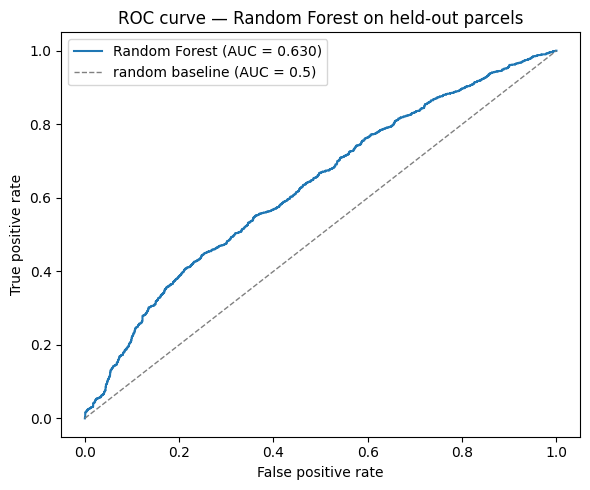

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='random baseline (AUC = 0.5)')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve — Random Forest on held-out parcels')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Permutation importance — which features matter

Shuffles each feature column and measures the drop in test ROC-AUC. The bigger the drop, the more the model relied on that feature.

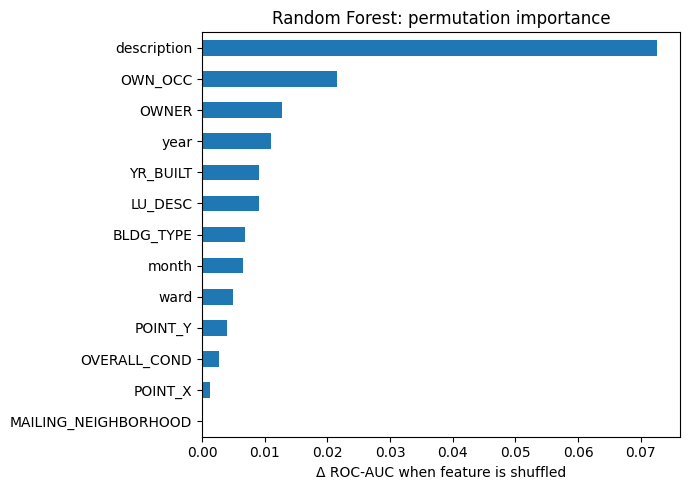

description             0.0726
OWN_OCC                 0.0216
OWNER                   0.0128
year                    0.0110
YR_BUILT                0.0091
LU_DESC                 0.0091
BLDG_TYPE               0.0068
month                   0.0066
ward                    0.0049
POINT_Y                 0.0040
OVERALL_COND            0.0027
POINT_X                 0.0012
MAILING_NEIGHBORHOOD    0.0002
dtype: float64

In [8]:
perm = permutation_importance(model, X_test, y_test,
                              n_repeats=3, scoring='roc_auc',
                              random_state=RANDOM_STATE, n_jobs=1)
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

plt.figure(figsize=(7, 5))
importance.plot.barh()
plt.xlabel('Δ ROC-AUC when feature is shuffled')
plt.title('Random Forest: permutation importance')
plt.tight_layout()
plt.show()

importance.sort_values(ascending=False).round(4)

## 9. Interpretation

- **Headline numbers:** ROC-AUC 0.630 and accuracy 0.402 on held-out parcels. ROC-AUC of 0.630 means the model ranks a random repeat-violation parcel above a random non-repeat parcel ~63% of the time — modest but meaningfully better than the 0.50 random baseline. Accuracy at the default 0.5 threshold is low (0.402) because the model's predicted probabilities on unseen parcels skew low; accuracy improves substantially with threshold tuning (see `modeling_final.ipynb`).

- **Why these numbers are different from the baseline `modeling.ipynb`:** the baseline reports 0.620 accuracy because it uses a random row-level split without group-awareness. With multiple violation records per parcel, that means most of any parcel's records appear in *both* train and test, so the model cannot generalize to new properties. Our group-aware split eliminates that issue — the resulting numbers are honest estimates of how well the model generalizes to *new* properties.

- **Most important feature: `description`** (the violation type) — TF-IDF on the description text contributes the largest single drop in ROC-AUC when shuffled. Owner identity, land-use type, and neighborhood/ward come next.

- **Practical takeaway:** at a 50% probability threshold the model is conservative — it correctly identifies most repeat parcels at high confidence but defaults to "no repeat" for borderline cases. For a real triage tool you would tune the threshold to match how many properties an inspector can actually audit (this notebook keeps the default 0.5 to keep the headline accuracy comparable to the baseline).